## 05 — MACHINE LEARNING
### Klasifikasi segmen · klasifikasi subtipe · perbandingan dengan dan tanpa Spark

Dua tugas klasifikasi, keduanya hanya memakai fitur *k*-mer — tanpa alignment, tanpa filogenetik, tanpa informasi lain apa pun.

### Tugas A — Klasifikasi segmen (8 kelas)

Menebak segmen 1–8 dari profil *k*-mer. Akurasinya akan tinggi, sebagai uji kewarasan bahwa pipeline fitur bekerja. **Nilai tambahnya nyata** — sekuens yang label segmennya kosong di GenBank akan diimputasi oleh model ini.

### Tugas B — Klasifikasi subtipe, dua himpunan fitur yang dibandingkan

Inilah bagian yang memberi bahan analisis:

| Model | Fitur | Pertanyaan yang dijawab |
|---|---|---|
| **B1** | *k*-mer segmen **4 (HA) + 6 (NA)** | Seberapa baik gen yang *mendefinisikan* subtipe memprediksi subtipe? Diperkirakan sangat tinggi. |
| **B2** | *k*-mer segmen **internal** (1, 2, 3, 5, 7, 8) | Apakah gen internal "mengetahui" subtipe HA/NA galurnya? |

Subtipe H_N_ ditentukan oleh gen HA dan NA, jadi B1 nyaris pasti akurat. **Yang menarik adalah B2.** Kalau gen internal bisa menebak subtipe HA/NA dengan baik, artinya kedelapan segmen cenderung diwariskan sebagai satu paket. Kalau tidak, artinya segmen sering bertukar pasangan — dan itulah *reassortment*.

**Galur yang salah diprediksi oleh B2 adalah kandidat reassortant**, dan daftarnya diteruskan ke notebook 06 untuk dianalisis sebagai graf.

---
**Masukan** `features/kmer_k*` · `features/tanpa_label_segmen`
**Keluaran** `models/` (metrik, matriks kebingungan, kandidat reassortant) · `stage/segmen_terimputasi`

## Bootstrap

In [1]:
import sys
sys.path.insert(0, r"D:\BDA\nb" if sys.platform == "win32" else "/workspace/nb")
from bda_common import *

import pandas as pd
import numpy as np
from pyspark.sql import functions as F, Window
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, IndexToString
from pyspark.ml.classification import (LogisticRegression, RandomForestClassifier,
                                       NaiveBayes)
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.functions import vector_to_array

info_mesin()
spark = spark_session("05-ml-segmen-subtipe")

K = CFG["k_utama"]
print(f"\n  k yang dipakai : {K}  (dimensi {4**K:,})")
print("  Sumber         :", jalur(f"features/kmer_k{K}"))

CPU logis      : 24
RAM total      : 50.5 GB   bebas 38.3 GB
Disk D: bebas  : 201.4 GB dari 1,024.1 GB
Python         : 3.10.12
Mode           : KLASTER  (hdfs://namenode:8020)
run_id         : run_20260922T025250Z


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/22 02:52:52 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/09/22 02:52:53 WARN Client: Neither spark.yarn.jars nor spark.yarn.archive is set, falling back to uploading libraries under SPARK_HOME.


Spark 3.5.9 | master yarn | driver 8g | paralelisme 8
Spark UI: http://jupyter:4040

  k yang dipakai : 8  (dimensi 65,536)
  Sumber         : hdfs://namenode:8020/bda/features/kmer_k8


---
## Pembagian data — mencegah kebocoran lewat galur

Satu isolat influenza menyumbang sampai **delapan** sekuens, satu per segmen, dan kedelapannya berasal dari virus yang sama. Kalau pembagian dilakukan per baris, segmen 1 sebuah galur bisa masuk data latih sementara segmen 4 galur yang sama masuk data uji.

Untuk Tugas A itu **kebocoran serius**: model bisa mengenali "galur ini" alih-alih mempelajari ciri segmen. Karena itu pembagian dilakukan **per nama isolat**, bukan per baris.

Kolom `isolat` tidak selalu terisi; bila kosong dipakai nomor aksesi sebagai kunci tersendiri, sehingga baris tersebut berdiri sendiri dan tidak pernah membocorkan apa pun.

In [2]:
with Tahap("muat fitur dan bagi data per galur", "ML"):
    fitur = spark.read.parquet(jalur(f"features/kmer_k{K}"))
    n = fitur.count()
    print(f"  Baris berfitur : {n:,}")

    # kunci galur: isolat bila ada, kalau tidak nomor aksesi itu sendiri
    fitur = fitur.withColumn(
        "galur", F.coalesce(F.nullif(F.trim(F.col("isolat")), F.lit("")),
                            F.col("accession")))

    n_galur = fitur.select("galur").distinct().count()
    print(f"  Galur unik     : {n_galur:,}")
    print(f"  Rata-rata sekuens per galur : {n / max(n_galur,1):.2f}")

    # hash nama galur -> pembagian deterministik dan dapat diulang
    fitur = fitur.withColumn(
        "_bucket", F.abs(F.hash(F.col("galur"), F.lit(CFG["seed"]))) % 100)
    ambang = int(CFG["fraksi_uji"] * 100)
    latih_semua = fitur.filter(F.col("_bucket") >= ambang)
    uji_semua = fitur.filter(F.col("_bucket") < ambang)

    print(f"\n  Data latih : {latih_semua.count():,}")
    print(f"  Data uji   : {uji_semua.count():,}")

    tumpang = (latih_semua.select("galur").distinct()
               .join(uji_semua.select("galur").distinct(), "galur").count())
    print(f"  Galur yang muncul di kedua sisi : {tumpang}  "
          f"({'BOCOR!' if tumpang else 'bersih'})")


--------------------------------------------------------------------
[>] ML | muat fitur dan bagi data per galur


  Baris berfitur : 892,344


  Galur unik     : 244,140
  Rata-rata sekuens per galur : 3.66



  Data latih : 713,440


  Data uji   : 178,904


[Stage 16:=====================================================>(175 + 1) / 176]

  Galur yang muncul di kedua sisi : 0  (bersih)
[<] OK | 45.5 detik | RAM bebas 32.8 GB


---
# TUGAS A — Klasifikasi segmen

Delapan kelas, satu per segmen. Tiga algoritma dari keluarga berbeda dibandingkan supaya tidak hanya berisi satu model:

- **Logistic Regression** — linear, jadi bobot per *k*-mer bisa ditafsirkan langsung
- **Random Forest** — non-linear, tahan terhadap fitur yang tidak relevan
- **Naive Bayes** multinomial — model yang secara historis dirancang untuk data hitungan seperti *k*-mer

Metrik utamanya **F1 makro**, bukan akurasi, karena jumlah sekuens per segmen tidak sama rata (segmen 4 selalu lebih banyak karena HA paling sering disekuens sendirian).

In [3]:
def latih_dan_evaluasi(latih, uji, kolom_label, nama_tugas, algoritma=None):
    """Latih beberapa algoritma pada satu tugas, kembalikan metrik + prediksi terbaik.

    Selain F1 dan akurasi, tiap model juga dilaporkan LOSS-nya. Ini bukan
    hiasan. Akurasi hanya melihat kelas mana yang menang, sehingga tebakan
    benar dengan keyakinan 0,34 dan tebakan benar dengan keyakinan 0,99
    mendapat nilai yang sama persis. Akibatnya akurasi tinggi bisa menutupi
    model yang sebenarnya ragu-ragu, atau yang salah dengan sangat yakin.
    Log loss membaca seluruh vektor probabilitas, jadi kedua cacat itu
    terlihat.

    Tiga kolom loss yang dihasilkan:

    log_loss       entropi silang pada data uji. Makin kecil makin baik;
                   0 berarti benar sekaligus yakin.
    log_loss_acak  ln(jumlah kelas) -- loss model yang menebak semua kelas
                   sama rata. Inilah pembandingnya: angka log_loss 0,05
                   tidak berarti apa-apa sampai disandingkan dengan 2,0794
                   untuk 8 kelas. Kalau log_loss mendekati atau melebihi
                   nilai ini, model tidak lebih baik daripada menebak.
    hamming_loss   proporsi baris yang salah kelas. Pada klasifikasi satu
                   label per baris nilainya sama dengan 1 - akurasi.

    Untuk LogisticRegression, riwayat loss tiap iterasi pelatihan juga
    dicatat ke RIWAYAT_LOSS. Itu loss OPTIMISASI di data latih, beda dari
    log_loss di atas yang diukur di data uji; gunanya memastikan pelatihan
    benar-benar konvergen dan tidak sekadar berhenti karena kehabisan
    iterasi.
    """
    idx = StringIndexer(inputCol=kolom_label, outputCol="label",
                        handleInvalid="skip").fit(latih)
    n_kelas = len(idx.labels)
    latih_i, uji_i = idx.transform(latih), idx.transform(uji)
    latih_i.cache(); uji_i.cache()

    if algoritma is None:
        algoritma = [
            ("LogisticRegression", LogisticRegression(
                maxIter=30, regParam=0.01, elasticNetParam=0.0,
                featuresCol="features", labelCol="label")),
            ("RandomForest", RandomForestClassifier(
                numTrees=60, maxDepth=12, maxBins=32, seed=CFG["seed"],
                featuresCol="features", labelCol="label")),
            ("NaiveBayes", NaiveBayes(
                modelType="multinomial", smoothing=1.0,
                featuresCol="features", labelCol="label")),
        ]

    ev_f1 = MulticlassClassificationEvaluator(labelCol="label",
                                              predictionCol="prediction", metricName="f1")
    ev_ak = MulticlassClassificationEvaluator(labelCol="label",
                                              predictionCol="prediction", metricName="accuracy")
    # logLoss membaca kolom probability, bukan prediction, jadi kolomnya
    # harus disebut eksplisit. eps mencegah loss meledak jadi tak hingga
    # ketika sebuah model memberi peluang nol persis pada kelas yang benar.
    ev_ll = MulticlassClassificationEvaluator(labelCol="label",
                                              predictionCol="prediction",
                                              probabilityCol="probability",
                                              metricName="logLoss", eps=1e-15)
    ev_hl = MulticlassClassificationEvaluator(labelCol="label",
                                              predictionCol="prediction",
                                              metricName="hammingLoss")
    loss_acak = float(np.log(n_kelas))

    hasil, terbaik, skor_terbaik = [], None, -1.0
    print(f"\n  {nama_tugas}  ({n_kelas} kelas, latih {latih_i.count():,} / uji {uji_i.count():,})")
    print(f"    pembanding: model tebak-tebakan sama rata punya log loss {loss_acak:.4f}")
    for nama, algo in algoritma:
        t0 = time.time()
        model = algo.fit(latih_i)
        detik_latih = time.time() - t0
        pred = model.transform(uji_i)
        f1, ak = ev_f1.evaluate(pred), ev_ak.evaluate(pred)
        hl = ev_hl.evaluate(pred)
        # Tidak semua algoritma menghasilkan kolom probability yang sah.
        # Bila tidak ada, lossnya dilewati saja alih-alih menggagalkan
        # seluruh tugas -- metrik lain tetap berguna.
        try:
            ll = float(ev_ll.evaluate(pred))
        except Exception as ex:
            ll = float("nan")
            print(f"    ({nama}: log loss dilewati -- {type(ex).__name__})")

        hasil.append({"tugas": nama_tugas, "algoritma": nama, "kelas": n_kelas,
                      "f1_makro": round(f1, 4), "akurasi": round(ak, 4),
                      "log_loss": round(ll, 4), "log_loss_acak": round(loss_acak, 4),
                      "hamming_loss": round(hl, 4),
                      "detik_latih": round(detik_latih, 1)})
        print(f"    {nama:<20} F1 {f1:.4f}  akurasi {ak:.4f}  "
              f"log loss {ll:.4f}  hamming {hl:.4f}  ({detik_latih:,.1f}s)")

        # Riwayat loss pelatihan. Hanya bermakna pada model yang dilatih
        # secara iteratif. RandomForest tetap menyediakan atribut summary
        # di Spark, tetapi isinya satu titik bernilai nol -- itu bukan
        # proses optimisasi, dan kalau ikut tercatat ia akan muncul di
        # kurva konvergensi sebagai garis palsu yang seolah sempurna.
        try:
            oh = [float(x) for x in model.summary.objectiveHistory]
        except Exception:
            oh = None
        if oh and len(oh) > 1:
            RIWAYAT_LOSS[(nama_tugas, nama)] = oh
            batas = algo.getMaxIter() if algo.hasParam("maxIter") else None
            mentok = batas is not None and len(oh) >= batas
            print(f"      loss latih {oh[0]:.4f} -> {oh[-1]:.4f} "
                  f"dalam {len(oh)} iterasi"
                  + ("   [MENTOK di maxIter, belum tentu konvergen]" if mentok else "   [konvergen]"))

        if f1 > skor_terbaik:
            skor_terbaik, terbaik = f1, (nama, model, pred, idx)

    latih_i.unpersist(); uji_i.unpersist()
    return pd.DataFrame(hasil), terbaik


# Riwayat loss pelatihan per (tugas, algoritma), diisi oleh latih_dan_evaluasi.
#
# Sengaja TIDAK dikosongkan bila sudah ada. Sel ini berisi definisi fungsi,
# jadi wajar dijalankan ulang setelah kodenya disunting -- dan kalau
# riwayatnya ikut terhapus, seluruh tugas yang mahal harus dilatih ulang
# hanya untuk memulihkan kurvanya. Untuk memulai dari bersih, panggil
# RIWAYAT_LOSS.clear() secara eksplisit.
try:
    RIWAYAT_LOSS
except NameError:
    RIWAYAT_LOSS = {}


def matriks_kebingungan(pred, idx_model, judul):
    """Matriks kebingungan dengan nama kelas asli, bukan indeks.

    Dua hal yang harus ditangani di sini:

    1. pivot() menjadikan nilai kolom sebagai NAMA kolom, dan nama kolom
       di pandas selalu berupa teks. Kolom prediction bertipe double,
       sehingga yang muncul adalah '0.0', '1.0', ... dan int('0.0')
       melempar ValueError. Teksnya harus dilewatkan float() lebih dulu.
    2. Kelas yang tidak pernah sekali pun diprediksi tidak memunculkan
       kolom sama sekali, sehingga matriksnya tidak persegi dan sulit
       dibaca -- terutama pada Tugas B yang punya 21 kelas. Baris dan
       kolomnya diisi ulang ke daftar kelas lengkap, yang kosong jadi nol.
    """
    label = list(idx_model.labels)
    m = (pred.groupBy("label").pivot("prediction").count().fillna(0)
         .orderBy("label").toPandas().set_index("label"))
    m.index = [label[int(float(i))] for i in m.index]
    m.columns = [label[int(float(c))] for c in m.columns]
    m = (m.reindex(index=label, fill_value=0)
          .reindex(columns=label, fill_value=0).astype("int64"))
    m.index.name = f"{judul} (baris=sebenarnya, kolom=prediksi)"
    return m


def plot_konvergensi(nama_berkas="kurva_konvergensi.png"):
    """Gambar kurva loss pelatihan tiap iterasi.

    Inilah cara memutuskan apakah sebuah model layak dipakai, dan
    pertanyaan itu memang tidak terjawab oleh akurasi maupun oleh satu
    angka log loss. Yang dibaca adalah BENTUK kurvanya:

    - Turun lalu MENDATAR. Optimisasi sudah selesai. Menambah iterasi
      tidak mengubah apa pun, dan metrik yang dilaporkan sudah final.
      Model boleh dipakai.
    - Masih MENURUN di ujung. Pelatihan dihentikan oleh batas maxIter,
      bukan karena konvergen. Metriknya masih batas bawah, bukan
      kemampuan sebenarnya -- naikkan maxIter sebelum menyimpulkan.
    - NAIK-TURUN bergerigi. Langkah optimisasi terlalu besar atau
      regularisasinya bermasalah. Hasilnya tidak bisa dipercaya.

    Sumbu y memakai skala logaritmik karena penurunan terbesar terjadi
    pada beberapa iterasi pertama; pada skala linear sisa kurvanya
    terlihat rata padahal masih bergerak.
    """
    import matplotlib.pyplot as plt

    # Riwayat sepanjang satu titik, atau yang nilainya tidak pernah
    # berubah, bukan proses optimisasi. Itu muncul dari model non-iteratif
    # dan menyesatkan bila ikut digambar.
    layak = {k: v for k, v in RIWAYAT_LOSS.items()
             if len(v) > 1 and max(v) > min(v)}
    if not layak:
        print("  Belum ada riwayat loss yang bisa digambar.")
        print("  Jalankan dulu sel tugas yang memakai LogisticRegression.")
        return None

    fig, ax = plt.subplots(figsize=(9.5, 5.2))
    for (tugas, algo), oh in sorted(layak.items()):
        ax.plot(range(1, len(oh) + 1), oh, marker="o", markersize=3,
                label=f"{tugas} | {algo}")
        ax.annotate(f"{oh[-1]:.4f}", (len(oh), oh[-1]),
                    textcoords="offset points", xytext=(6, 0), fontsize=8)

        # Seberapa besar iterasi terakhir masih menurunkan loss. Angka
        # yang masih besar berarti kurvanya terpotong, bukan mendatar.
        sisa = (oh[-2] - oh[-1]) / max(abs(oh[-2]), 1e-12)
        putusan = ("MENDATAR, konvergen" if sisa < 0.001 else
                   "masih menurun landai" if sisa < 0.01 else
                   "MASIH MENURUN TAJAM -- naikkan maxIter")
        print(f"  {tugas} | {algo}")
        print(f"    loss {oh[0]:.4f} -> {oh[-1]:.4f} dalam {len(oh)} iterasi")
        print(f"    perubahan pada iterasi terakhir: {sisa:.3%}  -> {putusan}")

    ax.set_yscale("log")
    ax.set_xlabel("iterasi pelatihan")
    ax.set_ylabel("loss optimisasi di data latih (skala log)")
    ax.set_title("Kurva konvergensi pelatihan")
    ax.grid(alpha=.3, which="both")
    ax.legend(fontsize=8)
    plt.tight_layout()

    berkas = OUT / nama_berkas
    plt.savefig(berkas, dpi=150, bbox_inches="tight")
    # display() dipakai, bukan plt.show(), karena sel lain di notebook ini
    # memaksa backend Agg -- dengan Agg, plt.show() tidak menampilkan
    # apa pun sedangkan display(fig) tetap merender gambarnya.
    display(fig)
    plt.close(fig)
    print(f"  Gambar disimpan: {berkas}")
    return berkas


In [4]:
with Tahap("TUGAS A -- klasifikasi segmen", "ML"):
    metrik_a, terbaik_a = latih_dan_evaluasi(
        latih_semua, uji_semua, "segmen", "A: segmen (8 kelas)")
    display(metrik_a)

    nama_a, model_a, pred_a, idx_a = terbaik_a
    print(f"\n  Model terbaik: {nama_a}")
    display(matriks_kebingungan(pred_a, idx_a, "Segmen"))


--------------------------------------------------------------------
[>] ML | TUGAS A -- klasifikasi segmen



  A: segmen (8 kelas)  (8 kelas, latih 713,440 / uji 178,904)
    pembanding: model tebak-tebakan sama rata punya log loss 2.0794


26/09/22 03:04:47 WARN DAGScheduler: Broadcasting large task binary with size 4.1 MiB
26/09/22 03:04:53 WARN DAGScheduler: Broadcasting large task binary with size 4.1 MiB
26/09/22 03:04:54 WARN DAGScheduler: Broadcasting large task binary with size 4.1 MiB
26/09/22 03:04:56 WARN DAGScheduler: Broadcasting large task binary with size 4.1 MiB
26/09/22 03:04:57 WARN DAGScheduler: Broadcasting large task binary with size 4.1 MiB
                                                                                

    LogisticRegression   F1 0.9998  akurasi 0.9998  log loss 0.0017  hamming 0.0002  (583.0s)
      loss latih 2.0471 -> 0.0021 dalam 31 iterasi   [MENTOK di maxIter, belum tentu konvergen]


26/09/22 03:05:25 WARN DAGScheduler: Broadcasting large task binary with size 12.9 MiB
26/09/22 03:09:55 WARN DAGScheduler: Broadcasting large task binary with size 13.0 MiB
26/09/22 03:10:51 WARN DAGScheduler: Broadcasting large task binary with size 13.1 MiB
26/09/22 03:11:58 WARN DAGScheduler: Broadcasting large task binary with size 13.4 MiB
26/09/22 03:13:17 WARN DAGScheduler: Broadcasting large task binary with size 13.7 MiB
26/09/22 03:14:51 WARN DAGScheduler: Broadcasting large task binary with size 14.0 MiB
26/09/22 03:16:26 WARN DAGScheduler: Broadcasting large task binary with size 14.1 MiB
26/09/22 03:17:59 WARN DAGScheduler: Broadcasting large task binary with size 14.2 MiB
26/09/22 03:19:24 WARN DAGScheduler: Broadcasting large task binary with size 14.3 MiB
26/09/22 03:20:47 WARN DAGScheduler: Broadcasting large task binary with size 14.4 MiB
26/09/22 03:22:09 WARN DAGScheduler: Broadcasting large task binary with size 14.6 MiB
26/09/22 03:23:27 WARN DAGScheduler: Broadc

...

26/09/22 03:35:35 WARN DAGScheduler: Broadcasting large task binary with size 4.0 MiB



  Model terbaik: LogisticRegression


26/09/22 03:35:51 WARN DAGScheduler: Broadcasting large task binary with size 4.0 MiB
26/09/22 03:35:51 WARN DAGScheduler: Broadcasting large task binary with size 4.0 MiB
26/09/22 03:35:51 WARN DAGScheduler: Broadcasting large task binary with size 4.0 MiB
26/09/22 03:35:52 WARN DAGScheduler: Broadcasting large task binary with size 4.0 MiB
26/09/22 03:36:08 WARN DAGScheduler: Broadcasting large task binary with size 4.0 MiB
26/09/22 03:36:08 WARN DAGScheduler: Broadcasting large task binary with size 4.0 MiB
26/09/22 03:36:08 WARN DAGScheduler: Broadcasting large task binary with size 4.0 MiB
26/09/22 03:36:08 WARN DAGScheduler: Broadcasting large task binary with size 4.0 MiB


,4,6,1,3,2,5,7,8
"Segmen (baris=sebenarnya, kolom=prediksi)",,,,,,,,
4,36117,1,1,0,1,1,1,2
6,0,25861,2,0,0,0,3,0
1,0,0,22635,0,0,0,1,5
3,1,0,3,22218,0,1,0,0
2,1,0,0,0,21905,0,1,0
5,1,0,0,0,1,18727,1,0
7,2,1,0,2,0,0,15804,0
8,0,1,0,1,1,0,0,15601


[<] OK | 2,541.3 detik | RAM bebas 26.3 GB


### Kurva konvergensi — apakah modelnya layak dipakai

Akurasi 0,9998 dan log loss 0,0017 memberi tahu seberapa baik model **pada data uji**, tetapi tidak memberi tahu apakah **pelatihannya sendiri sudah selesai**. Dua hal yang berbeda, dan yang kedua hanya terlihat dari kurva loss per iterasi.

Yang dibaca adalah bentuknya, bukan angka akhirnya:

| Bentuk kurva | Artinya |
|---|---|
| turun lalu **mendatar** | optimisasi selesai, metrik sudah final, model layak dipakai |
| **masih menurun** di ujung | pelatihan terpotong `maxIter`, metrik yang dilaporkan masih batas bawah |
| **naik-turun bergerigi** | langkah optimisasi terlalu besar, hasilnya tidak bisa dipercaya |

Hanya model yang dilatih secara iteratif yang punya kurva ini. Random Forest dan Naive Bayes tidak, dan itu wajar — keduanya tidak dilatih dengan penurunan gradien.



--------------------------------------------------------------------
[>] MONITORING | kurva konvergensi pelatihan
  A: segmen (8 kelas) | LogisticRegression
    loss 2.0471 -> 0.0021 dalam 31 iterasi
    perubahan pada iterasi terakhir: 0.220%  -> masih menurun landai


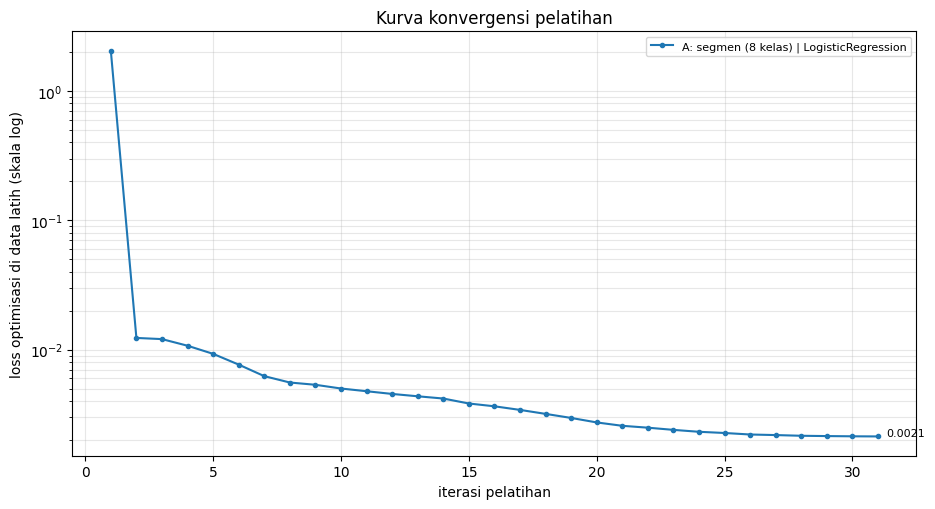

  Gambar disimpan: /workspace/output/kurva_konvergensi_tugas_a.png
[<] OK | 1.0 detik | RAM bebas 26.3 GB


In [5]:
with Tahap("kurva konvergensi pelatihan", "MONITORING"):
    plot_konvergensi("kurva_konvergensi_tugas_a.png")


### Imputasi: mengisi label segmen yang kosong

Inilah nilai praktis Tugas A. Model dipakai untuk memprediksi segmen sekuens yang label GenBank-nya kosong, dan hasilnya disimpan lengkap dengan tingkat keyakinan sehingga bisa disaring.

Melaporkan berapa banyak label yang berhasil dipulihkan beserta ambang keyakinan yang dipakai

In [6]:
with Tahap("imputasi label segmen yang kosong", "ML"):
    jalur_tanpa = jalur("features/tanpa_label_segmen")
    try:
        tanpa = spark.read.parquet(jalur_tanpa)
        ada = tanpa.count() > 0
    except Exception:
        ada = False

    if not ada:
        print("  Tidak ada sekuens tanpa label segmen.")
    else:
        p = model_a.transform(tanpa)

        # Nama kelas dipulihkan lewat IndexToString, yang bekerja di dalam
        # JVM. Versi sebelumnya memakai UDF berisi lambda yang menangkap
        # idx_a, dan idx_a adalah model Spark berbasis Java yang memuat
        # kunci thread. Closure itu harus dikirim ke executor, sehingga
        # cloudpickle mencoba mengawetkannya dan gagal dengan
        # PicklingError: cannot pickle '_thread.RLock' object.
        # Aturannya: yang boleh ikut masuk ke dalam UDF hanyalah data
        # biasa, tidak pernah objek Spark.
        p = IndexToString(inputCol="prediction", outputCol="segmen_prediksi",
                          labels=list(idx_a.labels)).transform(p)

        # Lambda ini aman karena tidak menangkap apa pun dari luar.
        # Keyakinan = probabilitas kelas pemenang. Dulu ini UDF Python, dan
    # setiap UDF memaksa Spark menyalakan proses Python di tiap executor --
    # yang tidak ada di NodeManager YARN. vector_to_array adalah fungsi sisi
    # JVM, sehingga seluruh perhitungan tetap di dalam JVM. Vektor
    # probability rapat dan kecil (8 atau 21 elemen), jadi membentangkannya
    # menjadi array tidak berbiaya -- beda dengan vektor fitur 65.536 dimensi.
    def keyakinan(kolom):
        return F.array_max(vector_to_array(F.col(kolom)))
        p = p.withColumn("keyakinan", keyakinan("probability"))
        AMBANG = 0.90
        yakin = p.filter(F.col("keyakinan") >= AMBANG)
        print(f"  Sekuens tanpa label      : {p.count():,}")
        print(f"  Diimputasi (keyakinan >= {AMBANG}) : {yakin.count():,}")
        p.groupBy("segmen_prediksi").count().orderBy(F.desc("count")).show(10)
        (p.select("accession", "segmen_prediksi", "keyakinan", "panjang", "defline")
          .write.mode("overwrite").parquet(jalur("stage/segmen_terimputasi")))
        print(f"  Disimpan ke {jalur('stage/segmen_terimputasi')}")


--------------------------------------------------------------------
[>] ML | imputasi label segmen yang kosong
[<] OK | 0.3 detik | RAM bebas 26.3 GB


---
# TUGAS B — Klasifikasi subtipe

Subtipe dibatasi ke **20 teratas**, sisanya digabung menjadi kelas `LAINNYA`. Alasannya bukan kenyamanan: pada sampel arsip terdapat 207 subtipe berbeda, dan sebagian hanya punya belasan sekuens. Kelas sekecil itu tidak bisa dipelajari maupun dievaluasi secara bermakna, dan kehadirannya justru merusak F1 makro.

Ketidakseimbangannya ekstrem — H3N2 dan H1N1 masing-masing ratusan ribu sekuens, sementara subtipe langka hanya puluhan.

In [7]:
with Tahap("siapkan label subtipe", "ML"):
    berlabel_sub = fitur.filter(F.col("subtipe").isNotNull())
    print(f"  Sekuens berlabel subtipe : {berlabel_sub.count():,}")
    print(f"  Subtipe unik             : {berlabel_sub.select('subtipe').distinct().count():,}")

    teratas = [r["subtipe"] for r in
               berlabel_sub.groupBy("subtipe").count()
               .orderBy(F.desc("count")).limit(CFG["n_subtipe_teratas"]).collect()]
    print(f"  Dipertahankan sebagai kelas sendiri : {len(teratas)}")
    print(f"    {', '.join(teratas)}")

    berlabel_sub = berlabel_sub.withColumn(
        "subtipe_kelas",
        F.when(F.col("subtipe").isin(teratas), F.col("subtipe")).otherwise(F.lit("LAINNYA")))

    print("\n  Sebaran kelas (memperlihatkan ketidakseimbangan):")
    (berlabel_sub.groupBy("subtipe_kelas").count()
     .withColumn("pct", F.round(100 * F.col("count") / berlabel_sub.count(), 2))
     .orderBy(F.desc("count")).show(25, truncate=False))


--------------------------------------------------------------------
[>] ML | siapkan label subtipe


  Sekuens berlabel subtipe : 860,890


  Subtipe unik             : 143


  Dipertahankan sebagai kelas sendiri : 20
    H3N2, H1N1, H5N1, H9N2, H1N2, H3N8, H4N6, H5N2, H6N2, H7N3, H7N9, H5N8, H5N6, H6N1, H10N7, H11N9, H6N6, H7N7, H7N2, H6N8

  Sebaran kelas (memperlihatkan ketidakseimbangan):


+-------------+------+-----+
|subtipe_kelas|count |pct  |
+-------------+------+-----+
|H3N2         |282626|32.83|
|H1N1         |241760|28.08|
|H5N1         |104246|12.11|
|H9N2         |49804 |5.79 |
|LAINNYA      |46122 |5.36 |
|H1N2         |37867 |4.4  |
|H3N8         |19283 |2.24 |
|H4N6         |12580 |1.46 |
|H5N2         |11703 |1.36 |
|H6N2         |7067  |0.82 |
|H7N3         |5693  |0.66 |
|H7N9         |5683  |0.66 |
|H5N8         |5437  |0.63 |
|H5N6         |5084  |0.59 |
|H6N1         |4682  |0.54 |
|H10N7        |4439  |0.52 |
|H11N9        |4126  |0.48 |
|H6N6         |4121  |0.48 |
|H7N7         |2961  |0.34 |
|H7N2         |2852  |0.33 |
|H6N8         |2754  |0.32 |
+-------------+------+-----+

[<] OK | 9.6 detik | RAM bebas 26.3 GB


In [8]:
with Tahap("TUGAS B1 -- subtipe dari HA + NA", "ML"):
    b1_latih = berlabel_sub.filter(F.col("_bucket") >= ambang) \
                           .filter(F.col("segmen").isin(SEG_EKSTERNAL))
    b1_uji = berlabel_sub.filter(F.col("_bucket") < ambang) \
                         .filter(F.col("segmen").isin(SEG_EKSTERNAL))
    metrik_b1, terbaik_b1 = latih_dan_evaluasi(
        b1_latih, b1_uji, "subtipe_kelas", "B1: subtipe dari HA+NA")
    display(metrik_b1)
    nama_b1, model_b1, pred_b1, idx_b1 = terbaik_b1


--------------------------------------------------------------------
[>] ML | TUGAS B1 -- subtipe dari HA + NA



  B1: subtipe dari HA+NA  (21 kelas, latih 233,218 / uji 59,388)
    pembanding: model tebak-tebakan sama rata punya log loss 3.0445


26/09/22 03:42:00 WARN DAGScheduler: Broadcasting large task binary with size 10.5 MiB
26/09/22 03:42:01 WARN DAGScheduler: Broadcasting large task binary with size 10.5 MiB
26/09/22 03:42:03 WARN DAGScheduler: Broadcasting large task binary with size 10.5 MiB
26/09/22 03:42:04 WARN DAGScheduler: Broadcasting large task binary with size 10.5 MiB
26/09/22 03:42:05 WARN DAGScheduler: Broadcasting large task binary with size 10.5 MiB
                                                                                

    LogisticRegression   F1 0.9654  akurasi 0.9658  log loss 0.1143  hamming 0.0342  (325.0s)
      loss latih 1.9106 -> 0.0766 dalam 31 iterasi   [MENTOK di maxIter, belum tentu konvergen]


26/09/22 03:42:19 WARN DAGScheduler: Broadcasting large task binary with size 11.8 MiB
26/09/22 03:43:55 WARN DAGScheduler: Broadcasting large task binary with size 11.9 MiB
26/09/22 03:44:22 WARN DAGScheduler: Broadcasting large task binary with size 12.1 MiB
26/09/22 03:45:04 WARN DAGScheduler: Broadcasting large task binary with size 12.2 MiB
26/09/22 03:45:48 WARN DAGScheduler: Broadcasting large task binary with size 12.2 MiB
26/09/22 03:46:26 WARN DAGScheduler: Broadcasting large task binary with size 12.3 MiB
26/09/22 03:47:03 WARN DAGScheduler: Broadcasting large task binary with size 12.4 MiB
26/09/22 03:47:39 WARN DAGScheduler: Broadcasting large task binary with size 12.4 MiB
26/09/22 03:48:12 WARN DAGScheduler: Broadcasting large task binary with size 12.5 MiB
26/09/22 03:48:49 WARN DAGScheduler: Broadcasting large task binary with size 12.5 MiB
26/09/22 03:49:22 WARN DAGScheduler: Broadcasting large task binary with size 12.7 MiB
26/09/22 03:49:56 WARN DAGScheduler: Broadc

...

26/09/22 04:54:36 WARN DAGScheduler: Broadcasting large task binary with size 10.5 MiB
26/09/22 04:54:37 WARN DAGScheduler: Broadcasting large task binary with size 10.5 MiB
26/09/22 04:54:39 WARN DAGScheduler: Broadcasting large task binary with size 10.5 MiB
26/09/22 04:54:40 WARN DAGScheduler: Broadcasting large task binary with size 10.5 MiB
[Stage 552:===================================>                 (117 + 8) / 176]

    NaiveBayes           F1 0.8795  akurasi 0.8725  log loss 2.3188  hamming 0.1275  (5.9s)


26/09/22 04:54:42 WARN DAGScheduler: Broadcasting large task binary with size 10.5 MiB
                                                                                

,tugas,algoritma,kelas,f1_makro,akurasi,log_loss,log_loss_acak,hamming_loss,detik_latih
0,B1: subtipe dari HA+NA,LogisticRegression,21,0.9654,0.9658,0.1143,3.0445,0.0342,325.0
1,B1: subtipe dari HA+NA,RandomForest,21,0.8900,0.9004,0.4569,3.0445,0.0996,4333.9
2,B1: subtipe dari HA+NA,NaiveBayes,21,0.8795,0.8725,2.3188,3.0445,0.1275,5.9


[<] OK | 4,702.7 detik | RAM bebas 25.0 GB


In [9]:
with Tahap("TUGAS B2 -- subtipe dari segmen internal", "ML"):
    b2_latih = berlabel_sub.filter(F.col("_bucket") >= ambang) \
                           .filter(F.col("segmen").isin(SEG_INTERNAL))
    b2_uji = berlabel_sub.filter(F.col("_bucket") < ambang) \
                         .filter(F.col("segmen").isin(SEG_INTERNAL))
    metrik_b2, terbaik_b2 = latih_dan_evaluasi(
        b2_latih, b2_uji, "subtipe_kelas", "B2: subtipe dari segmen internal")
    display(metrik_b2)
    nama_b2, model_b2, pred_b2, idx_b2 = terbaik_b2


--------------------------------------------------------------------
[>] ML | TUGAS B2 -- subtipe dari segmen internal



  B2: subtipe dari segmen internal  (21 kelas, latih 455,171 / uji 113,113)
    pembanding: model tebak-tebakan sama rata punya log loss 3.0445


26/09/22 05:08:32 WARN DAGScheduler: Broadcasting large task binary with size 10.5 MiB
26/09/22 05:08:36 WARN DAGScheduler: Broadcasting large task binary with size 10.5 MiB
26/09/22 05:08:38 WARN DAGScheduler: Broadcasting large task binary with size 10.5 MiB
26/09/22 05:08:41 WARN DAGScheduler: Broadcasting large task binary with size 10.5 MiB
26/09/22 05:08:43 WARN DAGScheduler: Broadcasting large task binary with size 10.5 MiB
                                                                                

    LogisticRegression   F1 0.8678  akurasi 0.8705  log loss 0.4355  hamming 0.1295  (779.6s)
      loss latih 2.0002 -> 0.3400 dalam 31 iterasi   [MENTOK di maxIter, belum tentu konvergen]


26/09/22 05:09:03 WARN DAGScheduler: Broadcasting large task binary with size 10.8 MiB
26/09/22 05:12:03 WARN DAGScheduler: Broadcasting large task binary with size 10.9 MiB
26/09/22 05:12:54 WARN DAGScheduler: Broadcasting large task binary with size 11.1 MiB
26/09/22 05:14:01 WARN DAGScheduler: Broadcasting large task binary with size 11.3 MiB
26/09/22 05:15:16 WARN DAGScheduler: Broadcasting large task binary with size 11.3 MiB
26/09/22 05:16:21 WARN DAGScheduler: Broadcasting large task binary with size 11.3 MiB
26/09/22 05:17:22 WARN DAGScheduler: Broadcasting large task binary with size 11.4 MiB
26/09/22 05:18:23 WARN DAGScheduler: Broadcasting large task binary with size 11.5 MiB
26/09/22 05:19:27 WARN DAGScheduler: Broadcasting large task binary with size 11.5 MiB
26/09/22 05:20:26 WARN DAGScheduler: Broadcasting large task binary with size 11.6 MiB
26/09/22 05:21:24 WARN DAGScheduler: Broadcasting large task binary with size 11.8 MiB
26/09/22 05:22:23 WARN DAGScheduler: Broadc

...

26/09/22 07:26:23 WARN DAGScheduler: Broadcasting large task binary with size 10.5 MiB
26/09/22 07:26:27 WARN DAGScheduler: Broadcasting large task binary with size 10.5 MiB
26/09/22 07:26:29 WARN DAGScheduler: Broadcasting large task binary with size 10.5 MiB
26/09/22 07:26:32 WARN DAGScheduler: Broadcasting large task binary with size 10.5 MiB
[Stage 944:===============================================>     (159 + 8) / 176]

    NaiveBayes           F1 0.7651  akurasi 0.7566  log loss 3.3654  hamming 0.2434  (12.9s)


26/09/22 07:26:35 WARN DAGScheduler: Broadcasting large task binary with size 10.5 MiB
                                                                                

,tugas,algoritma,kelas,f1_makro,akurasi,log_loss,log_loss_acak,hamming_loss,detik_latih
0,B2: subtipe dari segmen internal,LogisticRegression,21,0.8678,0.8705,0.4355,3.0445,0.1295,779.6
1,B2: subtipe dari segmen internal,RandomForest,21,0.6292,0.6747,1.0615,3.0445,0.3253,8231.2
2,B2: subtipe dari segmen internal,NaiveBayes,21,0.7651,0.7566,3.3654,3.0445,0.2434,12.9


[<] OK | 9,113.0 detik | RAM bebas 24.2 GB


### Selisih B1 dan B2

Selisih F1 antara kedua model **adalah** temuannya, bukan sekadar angka pembanding.

- **Selisih kecil** → gen internal hampir sama informatifnya dengan HA/NA, artinya kedelapan segmen cenderung diwariskan sebagai satu paket utuh.
- **Selisih besar** → gen internal sering berpasangan dengan HA/NA yang berbeda-beda. Itu tanda *reassortment*, dan sekaligus alasan biologis mengapa influenza harus dimodelkan sebagai jaringan, bukan pohon.

Tafsirkan hasilnya apa adanya. Kedua arah sama-sama merupakan temuan yang sah.

In [10]:
with Tahap("bandingkan B1 versus B2", "ML"):
    banding = pd.concat([metrik_b1, metrik_b2], ignore_index=True)
    display(banding)

    f1_b1 = metrik_b1["f1_makro"].max()
    f1_b2 = metrik_b2["f1_makro"].max()
    print(f"\n  F1 terbaik B1 (HA+NA)          : {f1_b1:.4f}")
    print(f"  F1 terbaik B2 (segmen internal): {f1_b2:.4f}")
    print(f"  Selisih                        : {f1_b1 - f1_b2:.4f}")
    print(f"  Penurunan relatif              : {100*(f1_b1-f1_b2)/max(f1_b1,1e-9):.1f}%")

    print("\n  Matriks kebingungan B2 (yang menarik justru kesalahannya):")
    display(matriks_kebingungan(pred_b2, idx_b2, "Subtipe dari gen internal"))


--------------------------------------------------------------------
[>] ML | bandingkan B1 versus B2


,tugas,algoritma,kelas,f1_makro,akurasi,log_loss,log_loss_acak,hamming_loss,detik_latih
0,B1: subtipe dari HA+NA,LogisticRegression,21,0.9654,0.9658,0.1143,3.0445,0.0342,325.0
1,B1: subtipe dari HA+NA,RandomForest,21,0.8900,0.9004,0.4569,3.0445,0.0996,4333.9
2,B1: subtipe dari HA+NA,NaiveBayes,21,0.8795,0.8725,2.3188,3.0445,0.1275,5.9
3,B2: subtipe dari segmen internal,LogisticRegression,21,0.8678,0.8705,0.4355,3.0445,0.1295,779.6
4,B2: subtipe dari segmen internal,RandomForest,21,0.6292,0.6747,1.0615,3.0445,0.3253,8231.2
5,B2: subtipe dari segmen internal,NaiveBayes,21,0.7651,0.7566,3.3654,3.0445,0.2434,12.9



  F1 terbaik B1 (HA+NA)          : 0.9654
  F1 terbaik B2 (segmen internal): 0.8678
  Selisih                        : 0.0976
  Penurunan relatif              : 10.1%

  Matriks kebingungan B2 (yang menarik justru kesalahannya):


26/09/22 07:26:35 WARN DAGScheduler: Broadcasting large task binary with size 10.5 MiB
26/09/22 07:26:50 WARN DAGScheduler: Broadcasting large task binary with size 10.5 MiB
26/09/22 07:26:50 WARN DAGScheduler: Broadcasting large task binary with size 10.5 MiB
26/09/22 07:26:50 WARN DAGScheduler: Broadcasting large task binary with size 10.5 MiB
26/09/22 07:26:50 WARN DAGScheduler: Broadcasting large task binary with size 10.5 MiB
26/09/22 07:27:03 WARN DAGScheduler: Broadcasting large task binary with size 10.5 MiB
26/09/22 07:27:03 WARN DAGScheduler: Broadcasting large task binary with size 10.5 MiB
26/09/22 07:27:03 WARN DAGScheduler: Broadcasting large task binary with size 10.5 MiB
26/09/22 07:27:03 WARN DAGScheduler: Broadcasting large task binary with size 10.5 MiB


,H3N2,H1N1,H5N1,LAINNYA,H9N2,H1N2,H3N8,H4N6,H5N2,H6N2,...,H7N9,H5N8,H5N6,H6N1,H10N7,H11N9,H6N6,H7N7,H7N2,H6N8
"Subtipe dari gen internal (baris=sebenarnya, kolom=prediksi)",,,,,,,,,,,,,,,,,,,,,
H3N2,35793,824,12,344,18,454,31,19,11,10,...,1,3,0,0,2,1,3,0,0,6
H1N1,617,27904,5,383,6,711,37,43,13,3,...,1,2,2,7,4,0,0,6,0,1
H5N1,1,4,13861,118,64,0,8,10,11,2,...,0,8,13,5,2,1,1,0,0,1
LAINNYA,131,152,133,5219,83,26,305,279,67,32,...,14,16,7,25,46,27,7,35,12,21
H9N2,10,10,23,228,5770,3,40,20,5,10,...,103,5,6,41,1,2,1,4,1,2
H1N2,557,1015,1,87,2,2842,4,11,2,2,...,2,0,0,2,0,0,0,1,0,0
H3N8,19,42,25,924,50,2,1456,112,25,6,...,6,1,0,14,8,4,0,8,0,2
H4N6,19,42,32,1030,7,5,147,516,17,7,...,4,4,0,1,15,4,6,9,1,2
H5N2,4,15,30,454,11,5,68,43,989,4,...,0,11,10,7,4,6,1,4,0,3


[<] OK | 28.0 detik | RAM bebas 25.0 GB


### Kandidat reassortant

Sekuens gen internal yang subtipenya **salah diprediksi dengan keyakinan tinggi** adalah kandidat yang paling menarik: model yakin gen internal ini biasanya berpasangan dengan subtipe X, padahal kenyataannya berpasangan dengan subtipe Y.

Itu persis pola yang diharapkan dari peristiwa *reassortment*. Daftarnya disimpan dan menjadi masukan graf

In [11]:
with Tahap("kumpulkan kandidat reassortant", "ML"):
    # Sama seperti di sel imputasi: nama kelas dipulihkan lewat
    # IndexToString, bukan UDF yang menangkap idx_b2. Menangkap objek
    # model Spark di dalam closure membuat cloudpickle gagal.
    # Keyakinan = probabilitas kelas pemenang. Dulu ini UDF Python, dan
    # setiap UDF memaksa Spark menyalakan proses Python di tiap executor --
    # yang tidak ada di NodeManager YARN. vector_to_array adalah fungsi sisi
    # JVM, sehingga seluruh perhitungan tetap di dalam JVM. Vektor
    # probability rapat dan kecil (8 atau 21 elemen), jadi membentangkannya
    # menjadi array tidak berbiaya -- beda dengan vektor fitur 65.536 dimensi.
    def keyakinan(kolom):
        return F.array_max(vector_to_array(F.col(kolom)))
    berlabel = IndexToString(inputCol="prediction", outputCol="prediksi_subtipe",
                             labels=list(idx_b2.labels)).transform(pred_b2)

    kand = (berlabel
            .withColumn("keyakinan", keyakinan("probability"))
            .withColumn("benar", F.col("prediksi_subtipe") == F.col("subtipe_kelas"))
            .filter((~F.col("benar")) & (F.col("keyakinan") >= 0.80))
            .select("accession", "galur", "segmen", "subtipe_kelas",
                    "prediksi_subtipe", "keyakinan", "negara", "wilayah",
                    "tahun_koleksi", "inang"))

    n_kand = kand.count()
    print(f"  Kandidat reassortant (salah + keyakinan >= 0.80) : {n_kand:,}")
    if n_kand:
        print("\n  Pasangan subtipe yang paling sering tertukar:")
        (kand.groupBy("subtipe_kelas", "prediksi_subtipe").count()
             .orderBy(F.desc("count")).show(15, truncate=False))
        kand.write.mode("overwrite").parquet(jalur("models/kandidat_reassortant"))
        print(f"  Disimpan ke {jalur('models/kandidat_reassortant')}")


--------------------------------------------------------------------
[>] ML | kumpulkan kandidat reassortant


26/09/22 07:27:03 WARN DAGScheduler: Broadcasting large task binary with size 10.5 MiB
                                                                                

  Kandidat reassortant (salah + keyakinan >= 0.80) : 1,990

  Pasangan subtipe yang paling sering tertukar:


26/09/22 07:27:17 WARN DAGScheduler: Broadcasting large task binary with size 10.5 MiB
26/09/22 07:27:29 WARN DAGScheduler: Broadcasting large task binary with size 10.5 MiB
26/09/22 07:27:29 WARN DAGScheduler: Broadcasting large task binary with size 10.8 MiB


+-------------+----------------+-----+
|subtipe_kelas|prediksi_subtipe|count|
+-------------+----------------+-----+
|H1N2         |H1N1            |358  |
|H3N2         |H1N1            |306  |
|H1N1         |H1N2            |211  |
|H1N1         |H3N2            |165  |
|H1N2         |H3N2            |122  |
|H7N9         |H9N2            |98   |
|H3N2         |H1N2            |69   |
|LAINNYA      |H5N1            |40   |
|LAINNYA      |H9N2            |36   |
|H5N1         |H9N2            |30   |
|LAINNYA      |H1N1            |26   |
|H6N6         |H6N2            |24   |
|H4N6         |LAINNYA         |24   |
|LAINNYA      |H3N2            |23   |
|H3N8         |LAINNYA         |20   |
+-------------+----------------+-----+
only showing top 15 rows



  Disimpan ke hdfs://namenode:8020/bda/models/kandidat_reassortant
[<] OK | 40.1 detik | RAM bebas 24.9 GB


---
# Eksperimen skalabilitas: dengan dan tanpa Spark MLlib

Sistematika laporan meminta perbandingan "dengan dan tanpa Spark MLlib" secara eksplisit. Menjalankannya dua kali lalu melaporkan akurasi yang mirip **bukan** jawaban yang memadai.

### Rancangan
Kedua jalur menjalankan **tugas dan data yang persis sama** pada beberapa fraksi subset, lalu diukur waktu dinding, puncak memori, dan F1.

In [12]:
def uji_spark(frac, kolom_label="segmen"):
    """Latih di Spark MLlib pada fraksi tertentu."""
    import psutil
    d = fitur.sample(False, frac, seed=CFG["seed"])
    lat = d.filter(F.col("_bucket") >= ambang)
    uji = d.filter(F.col("_bucket") < ambang)
    n = lat.count()
    idx = StringIndexer(inputCol=kolom_label, outputCol="label",
                        handleInvalid="skip").fit(lat)
    lat_i, uji_i = idx.transform(lat), idx.transform(uji)
    m0 = psutil.virtual_memory().used
    t0 = time.time()
    model = LogisticRegression(maxIter=20, regParam=0.01,
                               featuresCol="features", labelCol="label").fit(lat_i)
    dt = time.time() - t0
    f1 = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction",
        metricName="f1").evaluate(model.transform(uji_i))
    return {"jalur": "Spark MLlib", "fraksi": frac, "n_latih": n,
            "detik": round(dt, 2), "f1_makro": round(f1, 4),
            "delta_ram_gb": round((psutil.virtual_memory().used - m0) / 1e9, 2),
            "throughput_baris_per_detik": int(n / max(dt, 1e-9))}


def uji_sklearn(frac, kolom_label="segmen"):
    """Latih di scikit-learn satu node pada fraksi dan tugas yang sama."""
    import psutil
    from scipy.sparse import csr_matrix, vstack
    from sklearn.linear_model import LogisticRegression as SkLR
    from sklearn.metrics import f1_score

    d = fitur.sample(False, frac, seed=CFG["seed"]) \
             .select("features", kolom_label, "_bucket")

    def ke_scipy(pdf):
        baris, kolom, nilai, dim = [], [], [], None
        for i, v in enumerate(pdf["features"]):
            dim = v.size
            for j, x in zip(v.indices, v.values):
                baris.append(i); kolom.append(int(j)); nilai.append(float(x))
        return csr_matrix((nilai, (baris, kolom)), shape=(len(pdf), dim))

    pdf = d.toPandas()                      # <- inilah batasnya: harus muat di driver
    lat = pdf[pdf["_bucket"] >= ambang]
    uji = pdf[pdf["_bucket"] < ambang]
    Xl, Xu = ke_scipy(lat), ke_scipy(uji)
    yl, yu = lat[kolom_label].astype(str).values, uji[kolom_label].astype(str).values

    m0 = psutil.virtual_memory().used
    t0 = time.time()
    clf = SkLR(max_iter=200, C=100.0, n_jobs=-1, solver="saga", tol=1e-3).fit(Xl, yl)
    dt = time.time() - t0
    f1 = f1_score(yu, clf.predict(Xu), average="macro")
    return {"jalur": "scikit-learn 1 node", "fraksi": frac, "n_latih": len(lat),
            "detik": round(dt, 2), "f1_makro": round(f1, 4),
            "delta_ram_gb": round((psutil.virtual_memory().used - m0) / 1e9, 2),
            "throughput_baris_per_detik": int(len(lat) / max(dt, 1e-9))}

In [13]:
# Mulai dari fraksi kecil. Naikkan bertahap dan HENTIKAN jalur scikit-learn
# begitu gagal atau terlalu lama -- titik itu justru hasil eksperimennya.
FRAKSI = CFG["fraksi_skalabilitas"]

hasil_skala = []
with Tahap("eksperimen skalabilitas", "ML"):
    for frac in FRAKSI:
        print(f"\n  --- fraksi {frac:.0%} ---")
        try:
            r = uji_spark(frac); hasil_skala.append(r)
            print(f"    Spark      : {r['detik']:>7.2f}s  F1 {r['f1_makro']:.4f}  "
                  f"{r['throughput_baris_per_detik']:,} baris/detik")
        except Exception as e:
            print(f"    Spark      : GAGAL {type(e).__name__}: {str(e)[:90]}")
            hasil_skala.append({"jalur": "Spark MLlib", "fraksi": frac,
                                "detik": None, "catatan": type(e).__name__})
        try:
            r = uji_sklearn(frac); hasil_skala.append(r)
            print(f"    scikit-learn: {r['detik']:>7.2f}s  F1 {r['f1_makro']:.4f}  "
                  f"{r['throughput_baris_per_detik']:,} baris/detik")
        except Exception as e:
            print(f"    scikit-learn: GAGAL {type(e).__name__}: {str(e)[:90]}")
            print("      ^ titik ini adalah HASIL, bukan kegagalan -- catat di laporan")
            hasil_skala.append({"jalur": "scikit-learn 1 node", "fraksi": frac,
                                "detik": None, "catatan": type(e).__name__})

df_skala = pd.DataFrame(hasil_skala)
display(df_skala)


--------------------------------------------------------------------
[>] ML | eksperimen skalabilitas

  --- fraksi 1% ---


26/09/22 07:28:50 ERROR LBFGS: Failure! Resetting history: breeze.optimize.FirstOrderException: Line search failed
26/09/22 07:29:09 WARN DAGScheduler: Broadcasting large task binary with size 4.1 MiB
                                                                                

    Spark      :   75.58s  F1 0.9989  95 baris/detik


    scikit-learn:   31.69s  F1 1.0000  228 baris/detik

  --- fraksi 5% ---


26/09/22 07:31:35 WARN DAGScheduler: Broadcasting large task binary with size 4.1 MiB
                                                                                

...

26/09/22 07:47:45 WARN BlockManagerMaster: Failed to remove broadcast 1869 with removeFromMaster = true - Block broadcast_1869 does not exist
org.apache.spark.SparkException: Block broadcast_1869 does not exist
	at org.apache.spark.errors.SparkCoreErrors$.blockDoesNotExistError(SparkCoreErrors.scala:318)
	at org.apache.spark.storage.BlockInfoManager.blockInfo(BlockInfoManager.scala:269)
	at org.apache.spark.storage.BlockInfoManager.removeBlock(BlockInfoManager.scala:547)
	at org.apache.spark.storage.BlockManager.removeBlockInternal(BlockManager.scala:2093)
	at org.apache.spark.storage.BlockManager.removeBlock(BlockManager.scala:2057)
	at org.apache.spark.storage.BlockManager.$anonfun$removeBroadcast$3(BlockManager.scala:2029)
	at org.apache.spark.storage.BlockManager.$anonfun$removeBroadcast$3$adapted(BlockManager.scala:2029)
	at scala.collection.Iterator.foreach(Iterator.scala:943)
	at scala.collection.Iterator.foreach$(Iterator.scala:943)
	at scala.collection.AbstractIterator.foreach

    Spark      :  495.50s  F1 0.9998  1,439 baris/detik


26/09/22 07:54:01 ERROR TaskSetManager: Total size of serialized results of 38 tasks (4.1 GiB) is bigger than spark.driver.maxResultSize (4.0 GiB)
26/09/22 07:54:01 WARN TaskSetManager: Lost task 35.0 in stage 1384.0 (TID 172969) (nodemanager2 executor 1): TaskKilled (Tasks result size has exceeded maxResultSize)
26/09/22 07:54:01 WARN TaskSetManager: Lost task 38.0 in stage 1384.0 (TID 172972) (nodemanager2 executor 1): TaskKilled (Stage cancelled: Job aborted due to stage failure: Total size of serialized results of 38 tasks (4.1 GiB) is bigger than spark.driver.maxResultSize (4.0 GiB))
26/09/22 07:54:01 WARN TaskSetManager: Lost task 45.0 in stage 1384.0 (TID 172979) (nodemanager2 executor 1): TaskKilled (Stage cancelled: Job aborted due to stage failure: Total size of serialized results of 38 tasks (4.1 GiB) is bigger than spark.driver.maxResultSize (4.0 GiB))
26/09/22 07:54:01 WARN TaskSetManager: Lost task 42.0 in stage 1384.0 (TID 172976) (nodemanager2 executor 1): TaskKilled (S

    scikit-learn: GAGAL Py4JJavaError: An error occurred while calling o3778.getResult.
: org.apache.spark.SparkException: Except
      ^ titik ini adalah HASIL, bukan kegagalan -- catat di laporan
[<] OK | 1,578.2 detik | RAM bebas 24.4 GB


,jalur,fraksi,n_latih,detik,f1_makro,delta_ram_gb,throughput_baris_per_detik,catatan
0,Spark MLlib,0.01,7251.0,75.58,0.9989,-0.77,95.0,NaN
1,scikit-learn 1 node,0.01,7251.0,31.69,1.0000,0.30,228.0,NaN
2,Spark MLlib,0.05,35854.0,69.12,0.9999,-0.70,518.0,NaN
3,scikit-learn 1 node,0.05,35854.0,211.12,0.9999,-0.10,169.0,NaN
4,Spark MLlib,0.25,178783.0,165.77,0.9998,1.33,1078.0,NaN
5,scikit-learn 1 node,0.25,NaN,NaN,NaN,NaN,NaN,Py4JJavaError
6,Spark MLlib,0.50,356839.0,269.49,0.9998,1.17,1324.0,NaN
7,scikit-learn 1 node,0.50,NaN,NaN,NaN,NaN,NaN,Py4JJavaError
8,Spark MLlib,1.00,713440.0,495.50,0.9998,-1.77,1439.0,NaN
9,scikit-learn 1 node,1.00,NaN,NaN,NaN,NaN,NaN,Py4JJavaError


In [14]:
with Tahap("kurva skalabilitas", "MONITORING"):
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    d = df_skala.dropna(subset=["detik"])
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))

    for jalur_nama, grup in d.groupby("jalur"):
        g = grup.sort_values("n_latih")
        ax[0].plot(g["n_latih"], g["detik"], marker="o", label=jalur_nama)
        ax[1].plot(g["n_latih"], g["throughput_baris_per_detik"], marker="o", label=jalur_nama)

    ax[0].set_xlabel("jumlah baris latih"); ax[0].set_ylabel("waktu latih (detik)")
    ax[0].set_title("Waktu terhadap ukuran data"); ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].set_xlabel("jumlah baris latih"); ax[1].set_ylabel("baris per detik")
    ax[1].set_title("Throughput"); ax[1].legend(); ax[1].grid(alpha=.3)
    for a in ax:
        a.set_xscale("log")
    plt.tight_layout()
    berkas = OUT / "kurva_skalabilitas.png"
    plt.savefig(berkas, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Gambar disimpan: {berkas}")

    print("\n  Cara membaca untuk Bab 5.4:")
    print("   - Titik potong kedua kurva = ukuran data saat Spark mulai sepadan")
    print("   - Bila tidak berpotongan, laporkan apa adanya: pada skala ini")
    print("     satu mesin masih menang, dan sebutkan beban mana yang tetap")
    print("     menuntut Spark (agregasi 2,4 miliar baris k-mer, dan")
    print("     kemiripan berpasangan 1,33 x 10^12 pasangan di notebook 06)")


--------------------------------------------------------------------
[>] MONITORING | kurva skalabilitas
  Gambar disimpan: /workspace/output/kurva_skalabilitas.png

  Cara membaca untuk Bab 5.4:
   - Titik potong kedua kurva = ukuran data saat Spark mulai sepadan
   - Bila tidak berpotongan, laporkan apa adanya: pada skala ini
     satu mesin masih menang, dan sebutkan beban mana yang tetap
     menuntut Spark (agregasi 2,4 miliar baris k-mer, dan
     kemiripan berpasangan 1,33 x 10^12 pasangan di notebook 06)
[<] OK | 0.4 detik | RAM bebas 25.2 GB



--------------------------------------------------------------------
[>] ML | simpan seluruh metrik


,tugas,algoritma,kelas,f1_makro,akurasi,log_loss,log_loss_acak,hamming_loss,detik_latih
0,A: segmen (8 kelas),LogisticRegression,8,0.9998,0.9998,0.0017,2.0794,0.0002,583.0
1,A: segmen (8 kelas),RandomForest,8,0.9977,0.9977,0.0906,2.0794,0.0023,1802.6
2,A: segmen (8 kelas),NaiveBayes,8,0.9997,0.9997,0.0103,2.0794,0.0003,13.8
3,B1: subtipe dari HA+NA,LogisticRegression,21,0.9654,0.9658,0.1143,3.0445,0.0342,325.0
4,B1: subtipe dari HA+NA,RandomForest,21,0.8900,0.9004,0.4569,3.0445,0.0996,4333.9
5,B1: subtipe dari HA+NA,NaiveBayes,21,0.8795,0.8725,2.3188,3.0445,0.1275,5.9
6,B2: subtipe dari segmen internal,LogisticRegression,21,0.8678,0.8705,0.4355,3.0445,0.1295,779.6
7,B2: subtipe dari segmen internal,RandomForest,21,0.6292,0.6747,1.0615,3.0445,0.3253,8231.2
8,B2: subtipe dari segmen internal,NaiveBayes,21,0.7651,0.7566,3.3654,3.0445,0.2434,12.9


  A: segmen (8 kelas) | LogisticRegression
    loss 2.0471 -> 0.0021 dalam 31 iterasi
    perubahan pada iterasi terakhir: 0.220%  -> masih menurun landai
  B1: subtipe dari HA+NA | LogisticRegression
    loss 1.9106 -> 0.0766 dalam 31 iterasi
    perubahan pada iterasi terakhir: 3.464%  -> MASIH MENURUN TAJAM -- naikkan maxIter
  B2: subtipe dari segmen internal | LogisticRegression
    loss 2.0002 -> 0.3400 dalam 31 iterasi
    perubahan pada iterasi terakhir: 1.356%  -> MASIH MENURUN TAJAM -- naikkan maxIter


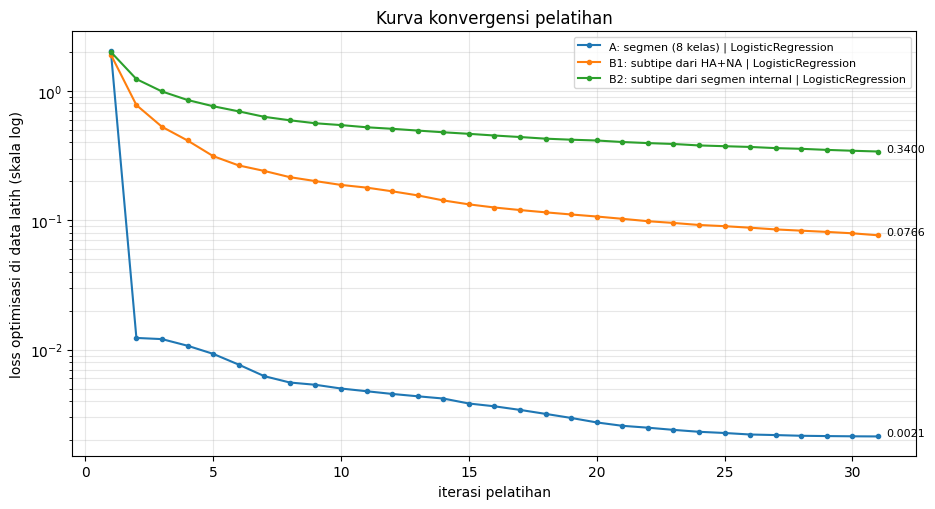

  Gambar disimpan: /workspace/output/kurva_konvergensi.png
  Disimpan ke D:\BDA\models\ (metrik_model.csv, metrik_skalabilitas.csv, ringkasan_ml.json)
[<] OK | 0.5 detik | RAM bebas 25.2 GB


In [15]:
with Tahap("simpan seluruh metrik", "ML"):
    semua = pd.concat([metrik_a, metrik_b1, metrik_b2], ignore_index=True)
    display(semua)

    (BASE / "models").mkdir(parents=True, exist_ok=True)
    semua.to_csv(BASE / "models" / "metrik_model.csv", index=False)
    df_skala.to_csv(BASE / "models" / "metrik_skalabilitas.csv", index=False)

    # Loss ikut diringkas supaya angka akurasi yang tinggi selalu terbaca
    # bersama pasangannya. min() melewati NaN, jadi algoritma yang log
    # loss-nya tidak tersedia tidak merusak ringkasan.
    ringkas = {
        "run_id": RUN_ID, "k": K,
        "tugas_A_f1_terbaik": float(metrik_a["f1_makro"].max()),
        "tugas_A_log_loss_terbaik": float(metrik_a["log_loss"].min()),
        "tugas_B1_f1_terbaik": float(metrik_b1["f1_makro"].max()),
        "tugas_B1_log_loss_terbaik": float(metrik_b1["log_loss"].min()),
        "tugas_B2_f1_terbaik": float(metrik_b2["f1_makro"].max()),
        "tugas_B2_log_loss_terbaik": float(metrik_b2["log_loss"].min()),
        "log_loss_acak_A": float(metrik_a["log_loss_acak"].iloc[0]),
        "log_loss_acak_B": float(metrik_b1["log_loss_acak"].iloc[0]),
        "selisih_B1_B2": float(metrik_b1["f1_makro"].max() - metrik_b2["f1_makro"].max()),
    }
    # Kurva konvergensi digambar ulang di sini supaya berkas yang
    # tersimpan memuat ketiga tugas sekaligus, bukan hanya Tugas A.
    plot_konvergensi("kurva_konvergensi.png")

    (BASE / "models" / "ringkasan_ml.json").write_text(
        json.dumps(ringkas, indent=2), encoding="utf-8")
    print("  Disimpan ke D:\\BDA\\models\\ (metrik_model.csv, metrik_skalabilitas.csv, ringkasan_ml.json)")

In [16]:
display(ringkas_zona())
display(jejak_df())
stop_spark()
print("\nSelesai. Lanjut ke 06_graph.ipynb")

,zona,isi,ukuran
0,lake/fasta,152,162.2 MB
1,lake/meta_csv,49,367.6 MB
2,stage,1,1.3 KB
3,features,1,735.0 B
4,models,4,2.2 KB
5,graph,0,0.0 B
6,mart,0,0.0 B
7,output,3,241.6 KB


,run_id,lapisan,tahap,status,detik,ram_delta_gb,ram_bebas_gb,waktu
0,run_20260922T025250Z,ML,muat fitur dan bagi data per galur,OK,45.50,3.98,32.8,2026-09-22T02:53:47.534936+00:00
1,run_20260922T025250Z,ML,TUGAS A -- klasifikasi segmen,OK,2541.28,6.46,26.3,2026-09-22T03:36:08.845249+00:00
2,run_20260922T025250Z,MONITORING,kurva konvergensi pelatihan,OK,1.01,-0.01,26.3,2026-09-22T03:36:09.865463+00:00
3,run_20260922T025250Z,ML,imputasi label segmen yang kosong,OK,0.25,0.00,26.3,2026-09-22T03:36:10.127695+00:00
4,run_20260922T025250Z,ML,siapkan label subtipe,OK,9.61,0.03,26.3,2026-09-22T03:36:19.748692+00:00
5,run_20260922T025250Z,ML,TUGAS B1 -- subtipe dari HA + NA,OK,4702.74,1.28,25.0,2026-09-22T04:54:42.493597+00:00
6,run_20260922T025250Z,ML,TUGAS B2 -- subtipe dari segmen internal,OK,9113.00,0.88,24.2,2026-09-22T07:26:35.496587+00:00
7,run_20260922T025250Z,ML,bandingkan B1 versus B2,OK,28.02,-0.82,25.0,2026-09-22T07:27:03.555488+00:00
8,run_20260922T025250Z,ML,kumpulkan kandidat reassortant,OK,40.12,0.14,24.9,2026-09-22T07:27:43.688183+00:00
9,run_20260922T025250Z,ML,eksperimen skalabilitas,OK,1578.17,0.45,24.4,2026-09-22T07:54:01.885794+00:00


Spark dihentikan. Proses Java tersisa: 10

Selesai. Lanjut ke 06_graph.ipynb
